In [1]:
from uxsim import *
from IPython.display import display, Image

In [2]:
W = WorldLocalChoice(
    name="simple_demo",    # Scenario name. Can be blank. Used as the folder name for saving results.
    deltan=5,   # Simulation aggregation unit Δn. Defines how many vehicles are grouped together (i.e., platoon size) for computation. Computation cost is generally inversely proportional to deltan^2.
    tmax=2000,  # Total simulation time (s)
    print_mode=1, save_mode=1, show_mode=1,    # Various options. print_mode determines whether to print information. Usually set to 1, but recommended 0 when running multiple simulations automatically. save_mode determines if visualization results are saved. show_mode determines if visualization results are displayed. It's good to set show_mode=1 on Jupyter Notebook, otherwise recommended 0.
    random_seed=380,    # Set the random seed. Specify if you want repeatable experiments. If not, set to None. 
    duo_update_weight=0.5,
    duo_update_time=100
)

In [3]:
W.addNode('nod0', 0.5, -1)
W.addNode("nod1", 1, 0)
W.addNode("nod2", 0, 1)
W.addNode("nod3", 1, 1)
W.addNode("nod4", 0, 2)
W.addNode("nod5", 1, 2)
W.addNode("nod6", 0.5, 3)

W.addLink('link0', 'nod0', 'nod1', length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W.addLink("link1", "nod1", "nod2", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5) # Create a link. Parameters: link name, start node, end node, length, free_flow_speed, number of lanes, merge_priority during merging
W.addLink("link2", "nod1", "nod3", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W.addLink("link3", "nod3", "nod2", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W.addLink("link4", "nod2", "nod4", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W.addLink("link5", "nod3", "nod5", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W.addLink("link6", "nod5", "nod4", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W.addLink("link7", "nod4", "nod6", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W.addLink("link8", "nod5", "nod6", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W.addLink("link9", "nod4", "nod5", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W.addLink("link10", "nod2", "nod3", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5) #1414

<Link link10>

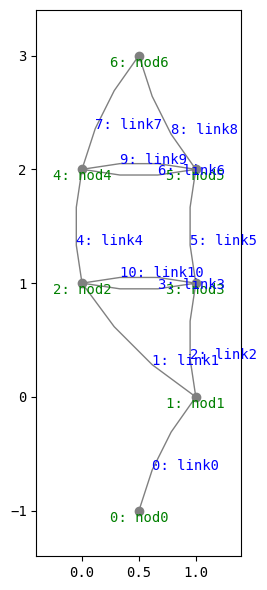

In [4]:
W.show_network()

In [5]:
W.adddemand("nod0", "nod6", 0, 500, 50) # Create OD traffic demand. Parameters: origin node, destination node, start time, end time, demand flow rate
#W.adddemand("nod1", "nod6", 0, 500, 50) # Create OD traffic demand. Parameters: origin node, destination node, start time, end time, demand flow rate
#W.adddemand("nod3", "nod2", 0, 500, 30) # Create OD traffic demand. Parameters: origin node, destination node, start time, end time, demand flow rate
#W.adddemand("nod2", "nod6", 0, 500, 5) # Create OD traffic demand. Parameters: origin node, destination node, start time, end time, demand flow rate

In [6]:
W.exec_simulation()

simulation setting:
 scenario name: simple_demo
 simulation duration:	 2000 s
 number of vehicles:	 25000 veh
 total road length:	 11000 m
 time discret. width:	 5 s
 platoon size:		 5 veh
 number of timesteps:	 400
 number of platoons:	 5000
 number of links:	 11
 number of nodes:	 7
 setup time:		 4.50 s
simulating...
      time| # of vehicles| ave speed| computation time
       0 s|        0 vehs|   0.0 m/s|     0.00 s


hello world!
hello world!
hello world!
hello world!
hello world!
hello world!
hello world!
hello world!
hello world!
hello world!
hello world!
weights [1. 1. 1. 1. 1. 1. 1.]
next_node_mask [[False False False False False False False False False False False]
 [False False False False False False False False False False False]
 [False False False False False False False False False False False]
 [False False False False False False False False False False False]
 [False False False False False False False False False False False]
 [False False False False False False False False False False False]
 [False False False False False False False False False False False]]
route matrix    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000
route matrix    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000
route matrix    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000 

1

In [7]:
W.analyzer.print_simple_stats() 

results:
 average speed:	 24.8 m/s
 number of completed trips:	 1455 / 25000
 average travel time of trips:	 1103.9 s
 average delay of trips:	 943.9 s
 delay ratio:			 0.855
 total distance traveled:	 9547750.0 m


 generating animation...


  0%|          | 0/200 [00:00<?, ?it/s]

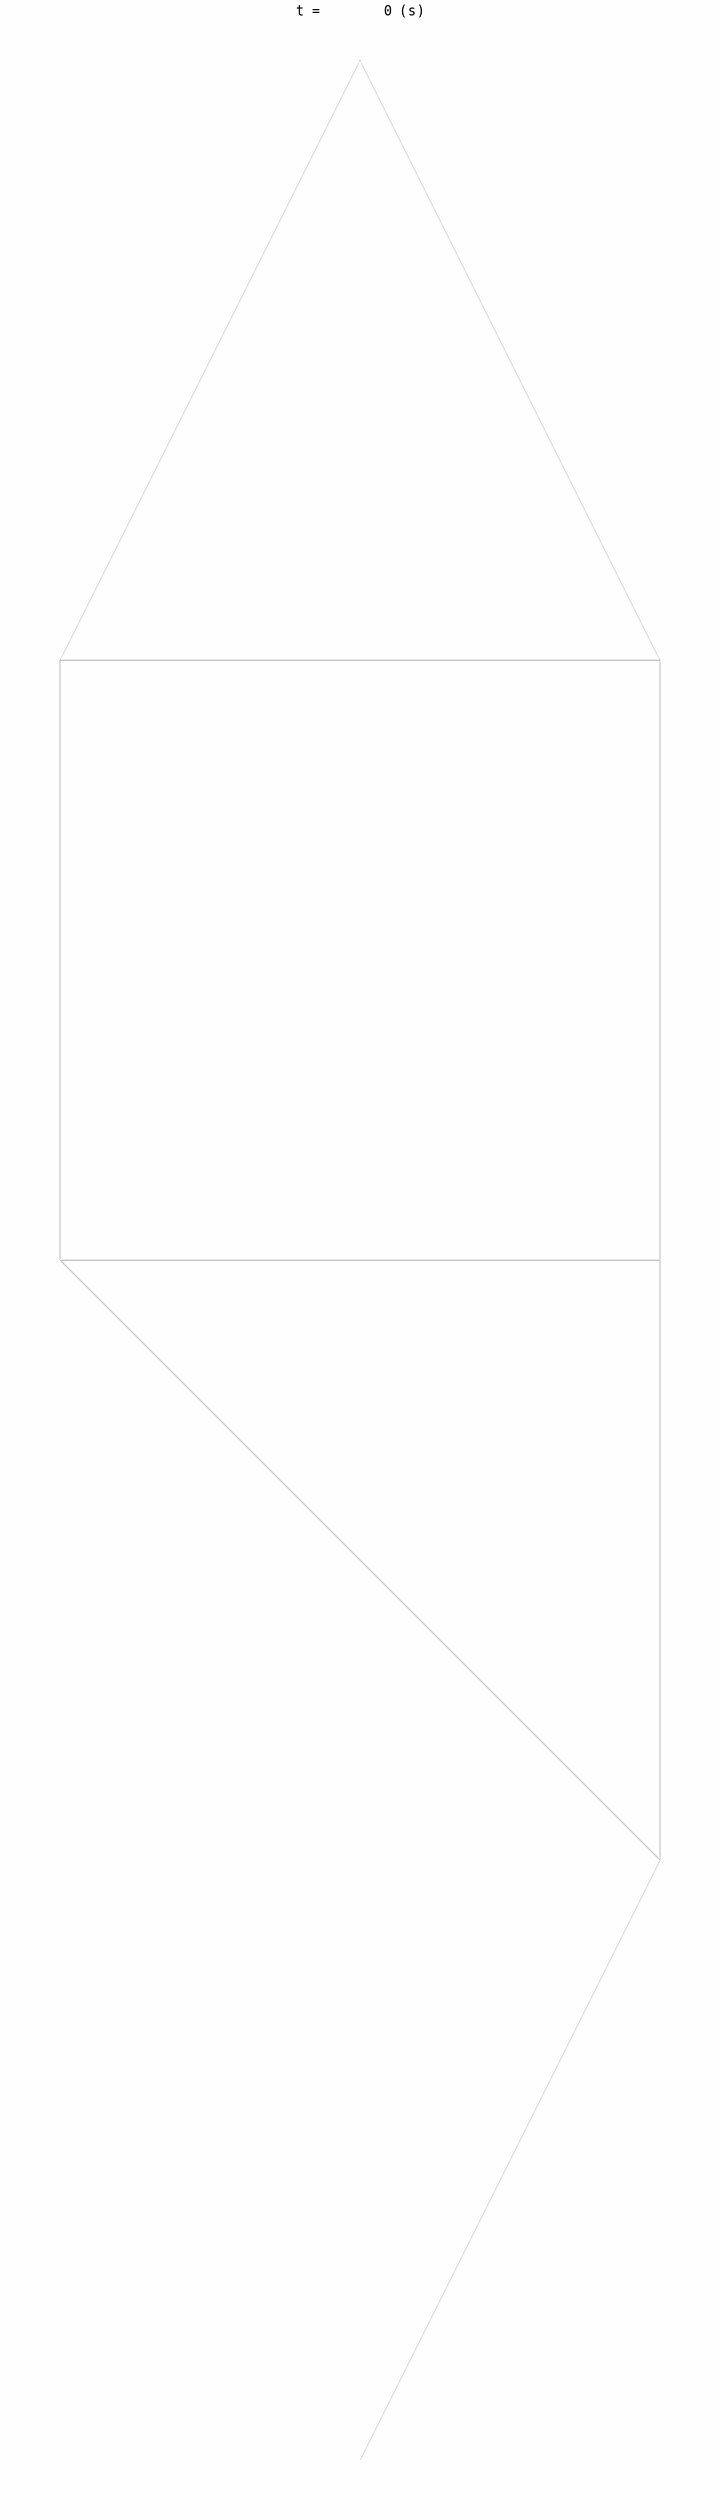

In [9]:
W.analyzer.network_fancy(animation_speed_inverse=15, sample_ratio=0.3, interval=3, trace_length=3, network_font_size=0)

with open("outsimple_demo/anim_network_fancy.gif", "rb") as f:
    display(Image(data=f.read(), format='png'))

 generating animation...


  0%|          | 0/14 [00:00<?, ?it/s]

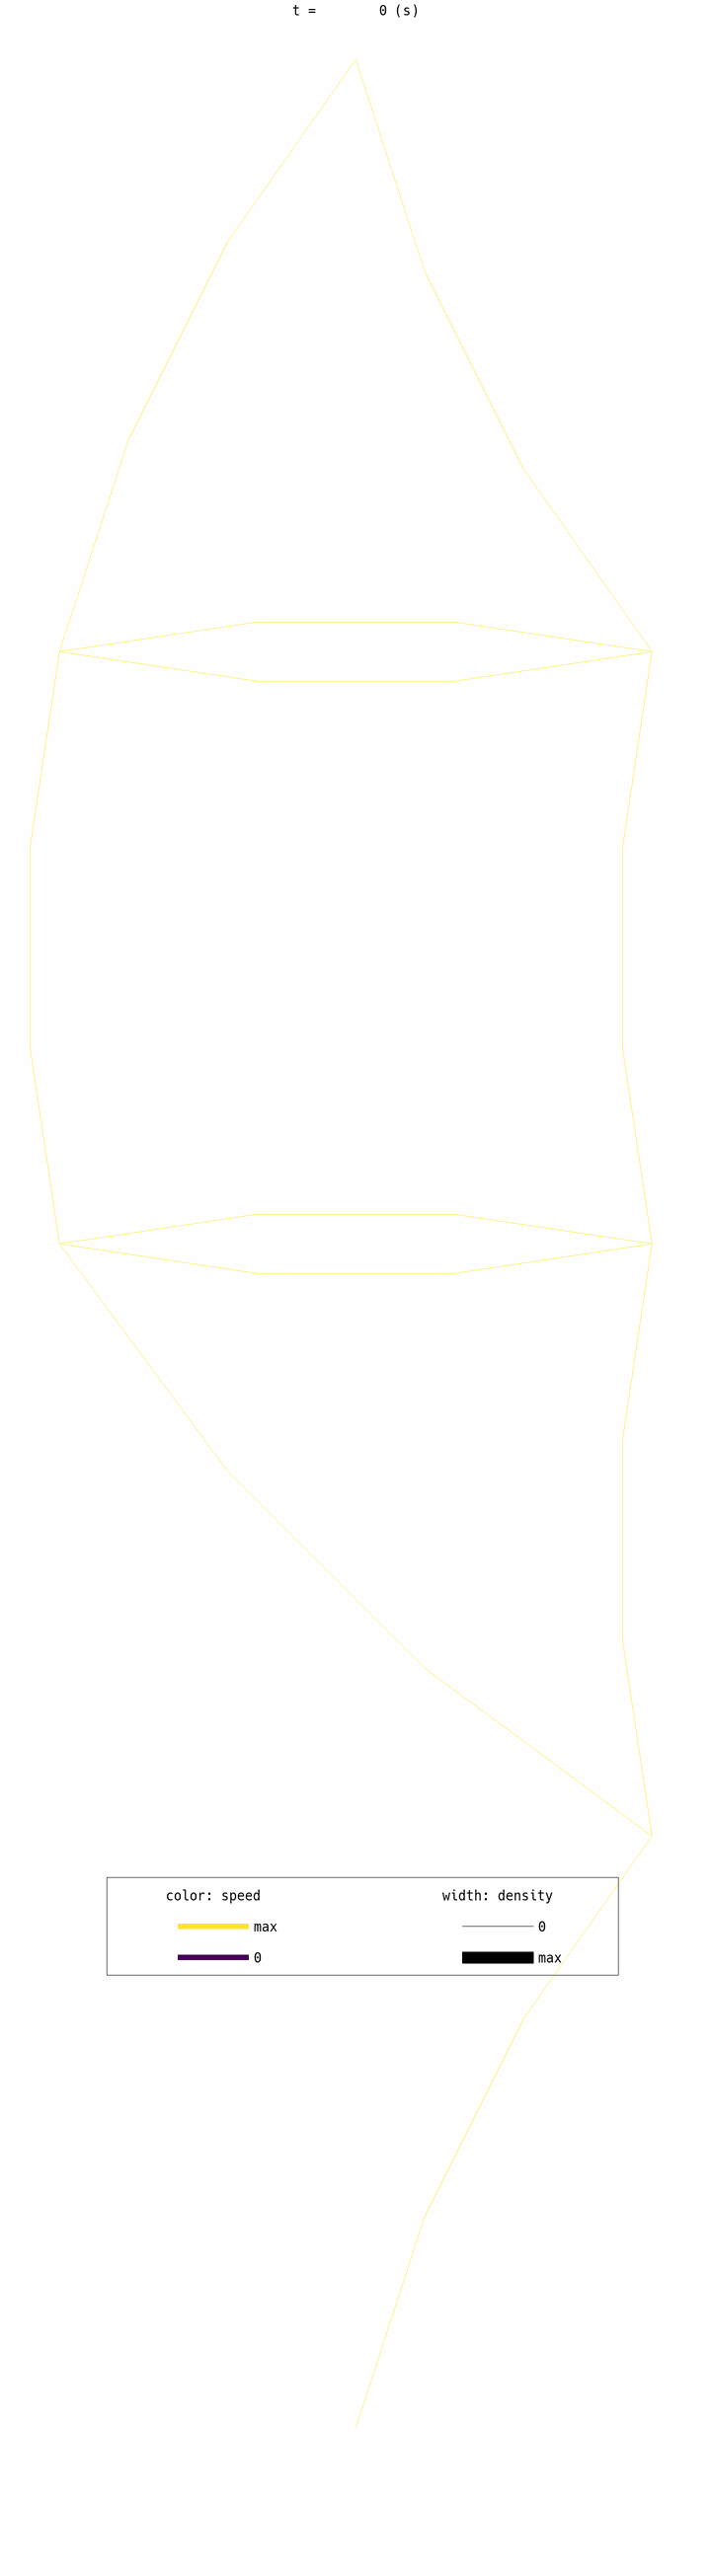

 generating animation...


  0%|          | 0/17 [00:00<?, ?it/s]

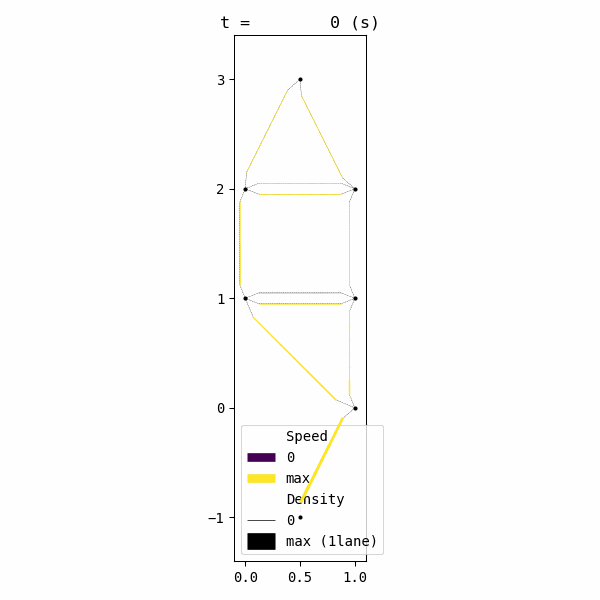

In [8]:
W.analyzer.network_anim(animation_speed_inverse=15, timestep_skip=30, detailed=0, figsize=(6,6), network_font_size=0)
from IPython.display import display, Image
with open("outsimple_demo/anim_network0.gif", "rb") as f:
    display(Image(data=f.read(), format='png'))
    
W.analyzer.network_anim(detailed=1, figsize=(6,6), network_font_size=0)

with open("outsimple_demo/anim_network1.gif", "rb") as f:
    display(Image(data=f.read(), format='png'))

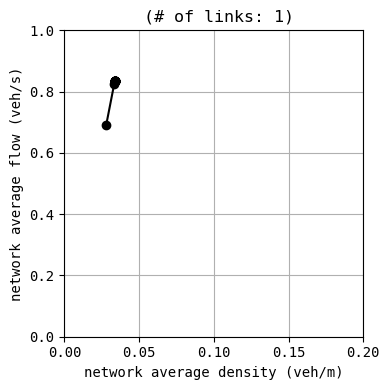

In [27]:
W.analyzer.macroscopic_fundamental_diagram(links=['link0'])

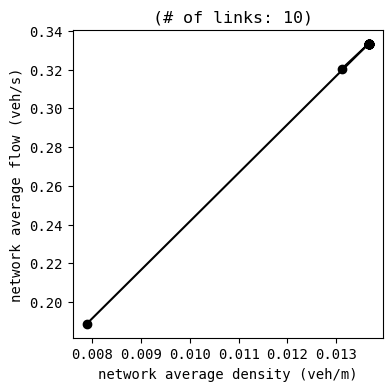

In [12]:
W.analyzer.macroscopic_fundamental_diagram('link1')

In [3]:
W.addNode("nod1", 0, 1)
W.addNode("nod2", 1, 1)
W.addNode("nod3", 2, 0)
W.addNode("nod4", 2, 2)
W.addNode("nod5", 3, 1)
W.addNode("nod6", 4, 1)

W.addLink("link1", "nod1", "nod2", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5) # Create a link. Parameters: link name, start node, end node, length, free_flow_speed, number of lanes, merge_priority during merging
W.addLink("link2", "nod2", "nod3", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.0)
W.addLink("link3", "nod2", "nod4", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.0)
W.addLink("link4", "nod3", "nod5", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W.addLink("link5", "nod4", "nod5", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W.addLink("link6", "nod4", "nod3", length=500, free_flow_speed=50, number_of_lanes=1, merge_priority=0.3)
W.addLink("link7", "nod5", "nod6", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)

<Link link7>

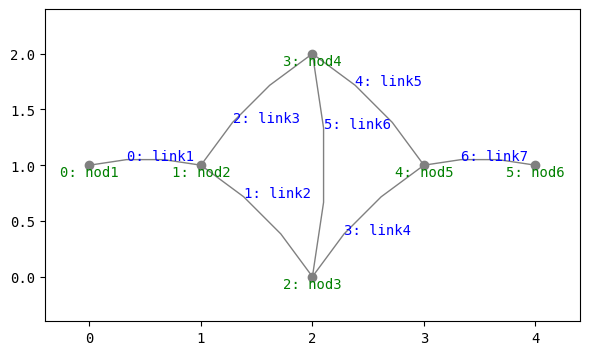

In [4]:
W.show_network()

In [5]:
W.adddemand("nod1", "nod6", 0, 800, 10) # Create OD traffic demand. Parameters: origin node, destination node, start time, end time, demand flow rate

In [6]:
W.exec_simulation()

simulation setting:
 scenario name: simple_demo
 simulation duration:	 1200 s
 number of vehicles:	 8000 veh
 total road length:	 6500 m
 time discret. width:	 5 s
 platoon size:		 5 veh
 number of timesteps:	 240
 number of platoons:	 1600
 number of links:	 7
 number of nodes:	 6
 setup time:		 0.27 s
simulating...
      time| # of vehicles| ave speed| computation time


       0 s|        0 vehs|   0.0 m/s|     0.00 s
     600 s|      130 vehs|  23.8 m/s|     0.22 s
    1200 s|      135 vehs|  23.5 m/s|     0.46 s
 simulation finished


1

In [7]:
W.analyzer.print_simple_stats() 

results:
 average speed:	 24.5 m/s
 number of completed trips:	 865 / 8000
 average travel time of trips:	 637.2 s
 average delay of trips:	 477.2 s
 delay ratio:			 0.749
 total distance traveled:	 3861125.0 m


 generating animation...


  0%|          | 0/8 [00:00<?, ?it/s]

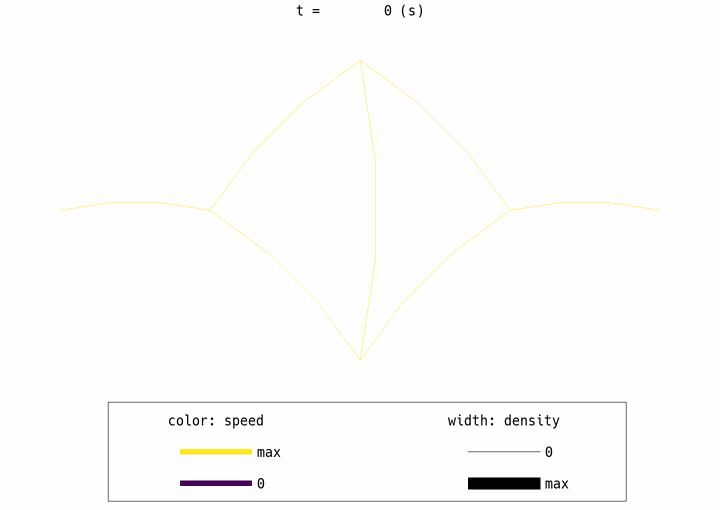

 generating animation...


  0%|          | 0/10 [00:00<?, ?it/s]

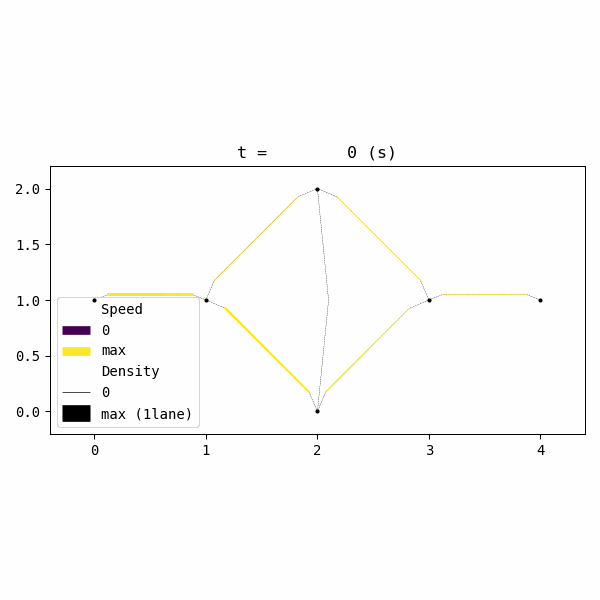

 generating animation...


  0%|          | 0/120 [00:00<?, ?it/s]

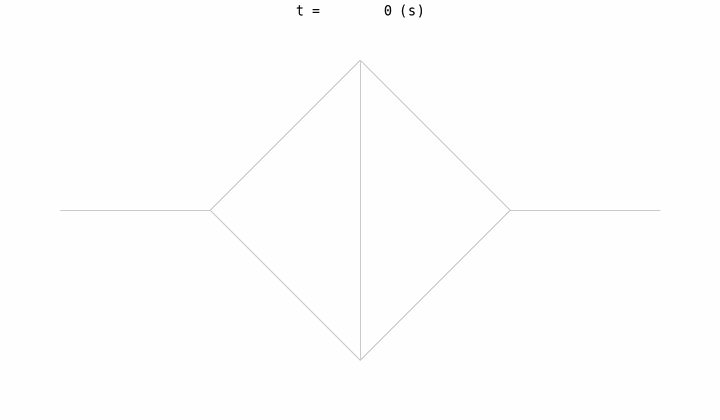

In [8]:
W.analyzer.network_anim(animation_speed_inverse=15, timestep_skip=30, detailed=0, figsize=(6,6), network_font_size=0)
from IPython.display import display, Image
with open("outsimple_demo/anim_network0.gif", "rb") as f:
    display(Image(data=f.read(), format='png'))
    
W.analyzer.network_anim(detailed=1, figsize=(6,6), network_font_size=0)

with open("outsimple_demo/anim_network1.gif", "rb") as f:
    display(Image(data=f.read(), format='png'))

W.analyzer.network_fancy(animation_speed_inverse=20, sample_ratio=0.3, interval=3, trace_length=3, network_font_size=0)

with open("outsimple_demo/anim_network_fancy.gif", "rb") as f:
    display(Image(data=f.read(), format='png'))

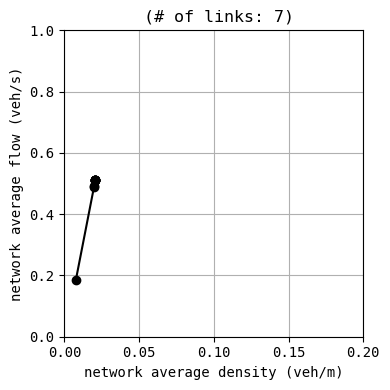

In [9]:
W.analyzer.macroscopic_fundamental_diagram()

In [1]:
from uxsim import *
W = World(
    name="simple_demo",    # Scenario name. Can be blank. Used as the folder name for saving results.
    deltan=5,   # Simulation aggregation unit Δn. Defines how many vehicles are grouped together (i.e., platoon size) for computation. Computation cost is generally inversely proportional to deltan^2.
    tmax=1200,  # Total simulation time (s)
    print_mode=1, save_mode=1, show_mode=1,    # Various options. print_mode determines whether to print information. Usually set to 1, but recommended 0 when running multiple simulations automatically. save_mode determines if visualization results are saved. show_mode determines if visualization results are displayed. It's good to set show_mode=1 on Jupyter Notebook, otherwise recommended 0.
    random_seed=0    # Set the random seed. Specify if you want repeatable experiments. If not, set to None. 
)

In [2]:
W.addNode("nod1", 0, 0) #Create a node. Parameters: node name, visualization x-coordinate, visualization y-coordinate
W.addNode("nod2", 0, 3)
W.addNode("nod3", 0, 2)
W.addNode("nod4", 1, 0)
W.addNode("nod5", 1, 1)
W.addNode("nod6", 1, 2)
W.addNode("nod7", 2, 0)
W.addNode("nod8", 2, 1)
W.addNode("nod9", 2, 3)
W.addNode("nod10", 3, 4)
W.addNode("nod11", 1, 4)
W.addNode("nod12", 3, 1)

W.addLink("link1", "nod1", "nod3", length=2000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5) # Create a link. Parameters: link name, start node, end node, length, free_flow_speed, number of lanes, merge_priority during merging
W.addLink("link2", "nod2", "nod3", length=1000, free_flow_speed=20, number_of_lanes=1, merge_priority=0.8)
W.addLink("link3", "nod3", "nod6", length=1000, free_flow_speed=20, number_of_lanes=1, merge_priority=1.2)
W.addLink("link4", "nod1", "nod4", length=1000, free_flow_speed=20, number_of_lanes=1, merge_priority=0.8)
W.addLink("link5", "nod1", "nod5", length=1414, free_flow_speed=20, number_of_lanes=1, merge_priority=1.2)
W.addLink("link6", "nod4", "nod5", length=1000, free_flow_speed=20, number_of_lanes=1, merge_priority=1)
W.addLink("link7", "nod4", "nod7", length=1000, free_flow_speed=20, number_of_lanes=1, merge_priority=1.2)
W.addLink("link8", "nod7", "nod8", length=1000, free_flow_speed=20, number_of_lanes=1, merge_priority=1.2)
W.addLink("link9", "nod7", "nod12", length=1414, free_flow_speed=25, number_of_lanes=1, merge_priority=0.7)
W.addLink("link10", "nod5", "nod8", length=1000, free_flow_speed=20, number_of_lanes=1, merge_priority=2.5)
W.addLink("link11", "nod5", "nod6", length=1000, free_flow_speed=20, number_of_lanes=1, merge_priority=1.5)
W.addLink("link12", "nod8", "nod12", length=1000, free_flow_speed=20, number_of_lanes=1, merge_priority=1)
W.addLink("link13", "nod8", "nod10", length=3162, free_flow_speed=30, number_of_lanes=1, merge_priority=0.9)
W.addLink("link14", "nod6", "nod2", length=1414, free_flow_speed=22, number_of_lanes=1, merge_priority=1.2)
W.addLink("link15", "nod6", "nod9", length=1414, free_flow_speed=23, number_of_lanes=1, merge_priority=2)
W.addLink("link16", "nod6", "nod11", length=2000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.1)
W.addLink("link17", "nod11", "nod10", length=2000, free_flow_speed=27, number_of_lanes=1, merge_priority=1.2)
W.addLink("link18", "nod9", "nod12", length=2236, free_flow_speed=27, number_of_lanes=1, merge_priority=0.8)
W.addLink("link19", "nod2", "nod11", length=1414, free_flow_speed=28, number_of_lanes=1, merge_priority=2.5)


<Link link19>

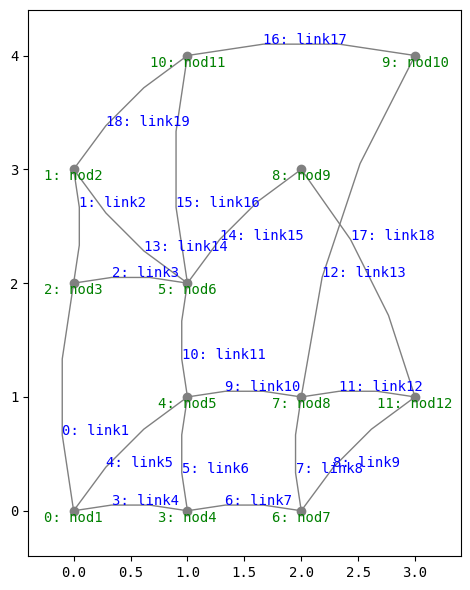

In [3]:
W.show_network()

In [4]:
#W.adddemand("nod1", "nod9", 500, 1000, 0.5) # Create OD traffic demand. Parameters: origin node, destination node, start time, end time, demand flow rate
#W.adddemand("nod12", "nod11", 200, 800, 0.9)
#W.adddemand("nod9", "nod10", 0, 1000, 0.8)
#W.adddemand("nod2", "nod7", 400, 1000, 0.7)
#W.adddemand("nod7", "nod11", 0, 500, 0.6)

W.adddemand("nod7", "nod11", 0, 1000, 0.9)
W.adddemand("nod11", "nod7", 0, 1000, 0.9)

In [5]:
W.exec_simulation()

simulation setting:
 scenario name: simple_demo
 simulation duration:	 1200 s
 number of vehicles:	 1800 veh
 total road length:	 27468 m
 time discret. width:	 5 s
 platoon size:		 5 veh
 number of timesteps:	 240
 number of platoons:	 360
 number of links:	 19
 number of nodes:	 12
 setup time:		 6.49 s
simulating...
      time| # of vehicles| ave speed| computation time
       0 s|        0 vehs|   0.0 m/s|     0.00 s
     600 s|      140 vehs|  24.7 m/s|     0.06 s
    1200 s|        0 vehs|   0.0 m/s|     0.09 s
 simulation finished


1

In [6]:
W.analyzer.print_simple_stats()

results:
 average speed:	 25.2 m/s
 number of completed trips:	 0 / 1800
 total distance traveled:	 0.0 m


 generating animation...


  0%|          | 0/8 [00:00<?, ?it/s]

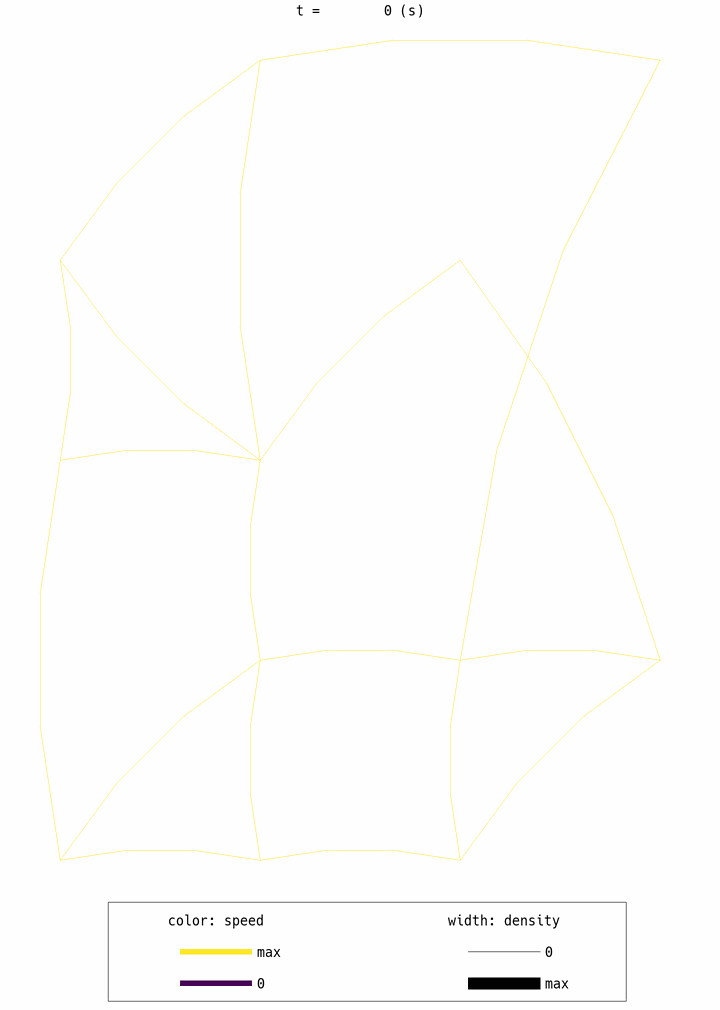

 generating animation...


  0%|          | 0/10 [00:00<?, ?it/s]

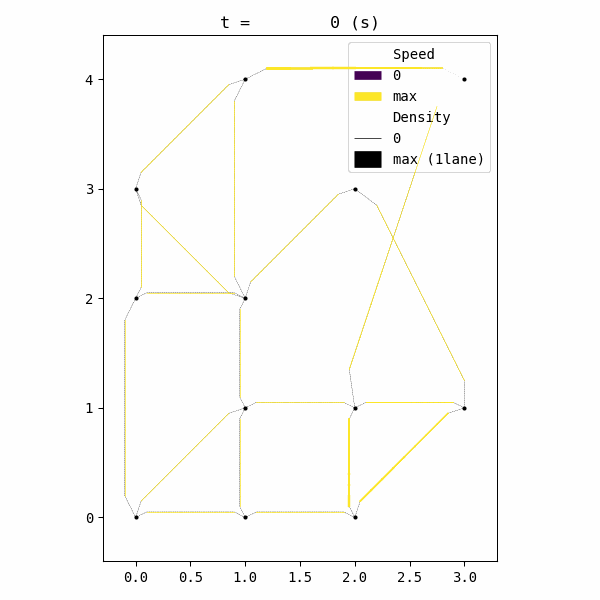

 generating animation...


  0%|          | 0/120 [00:00<?, ?it/s]

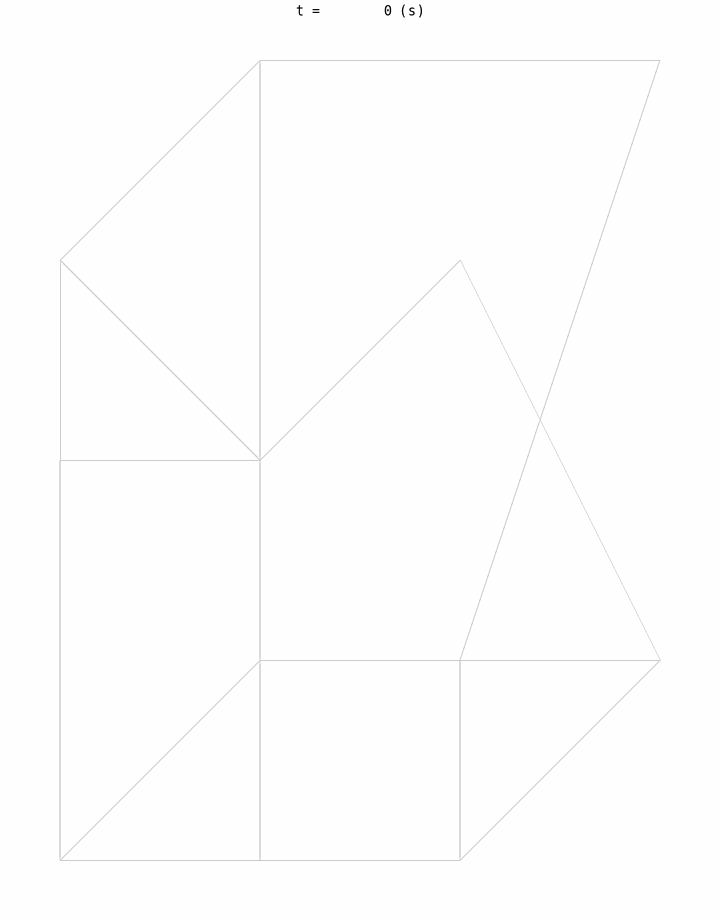

In [7]:
W.analyzer.network_anim(animation_speed_inverse=15, timestep_skip=30, detailed=0, figsize=(6,6), network_font_size=0)
from IPython.display import display, Image
with open("outsimple_demo/anim_network0.gif", "rb") as f:
    display(Image(data=f.read(), format='png'))
    
W.analyzer.network_anim(detailed=1, figsize=(6,6), network_font_size=0)

with open("outsimple_demo/anim_network1.gif", "rb") as f:
    display(Image(data=f.read(), format='png'))

W.analyzer.network_fancy(animation_speed_inverse=15, sample_ratio=0.3, interval=3, trace_length=3, network_font_size=0)

with open("outsimple_demo/anim_network_fancy.gif", "rb") as f:
    display(Image(data=f.read(), format='png'))

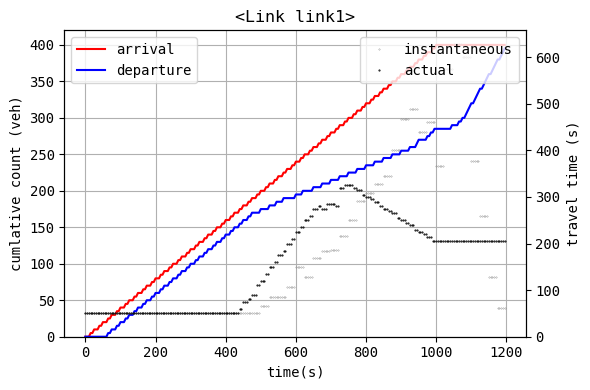

In [10]:
W.analyzer.cumulative_curves(['link1'])

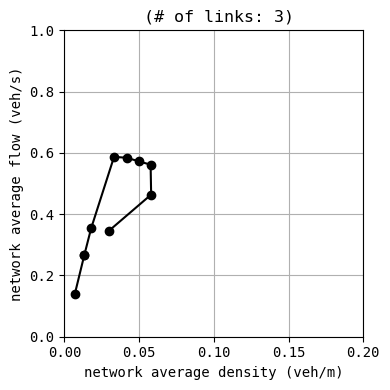

In [16]:
W.analyzer.macroscopic_fundamental_diagram()

In [159]:
import networkx as nx
import numpy as np
import math
from networkx.generators.lattice import grid_2d_graph

In [167]:
def create_oriented_lattice(size=5):
    """
    generates a simple square lattice graph of side (number of nodes horinzontally and vertically) 'size'

    nodes are relabeled from 0 to 'size'^2-1

    nodes hold their position as attributes ('pos')
    """
    latt = grid_2d_graph(size,size,periodic=False, create_using=nx.DiGraph())
    pos={n:n for n in latt.nodes}
    nx.set_node_attributes(latt, pos,'pos')
    mapping = {n:i for i,n in enumerate(latt.nodes)}
    latt = nx.relabel_nodes(latt, mapping)
    return latt
    
def populate_agents(network, n_agents):
    """
    just returns an array with 'n_agents' random node labels 
    """
    max_ind_pos = network.number_of_nodes() 
    pos_agents = np.random.randint(low=0, high=max_ind_pos,size=n_agents, dtype=int)

    positions = np.zeros((n_agents,2), dtype=int)
    positions[:,1] = pos_agents

    return positions

def generate_trips(network, n_agents, agents_positions):
    """
    returns an array of 'n_agents' destinations pairs
    """
    destinations = np.zeros(n_agents,dtype=int)
    for i in range(n_agents):
        d = np.random.randint(low=0, high=network.number_of_nodes(),size=1)
        while d == agents_positions[i]:
            d = np.random.randint(low=0, high=network.number_of_nodes(),size=1)
        destinations[i] = d
    return destinations

def assign_weights(network):
    weight_edges = {}
    for u,v in network.edges:
        pu,pv = network.nodes[u]['pos'], network.nodes[v]['pos']
        weight_edges[(u,v)] = math.dist(pu,pv)
    nx.set_edge_attributes(network, weight_edges, "length_km") 
    return network

In [179]:
if __name__=='__main__':
    # optimization horizon
    T = 2

    # initialize a simple network
    # FOR ALL THE NETWORKS THAT WE WILL USE, WE LABEL THEIR NODES BY INTEGERS
    # FROM 0 to N-1
    size_network = 25
    network = create_oriented_lattice(size_network)

    network = assign_weights(network)

    # list of edges
    edges = [(u,v) for (u,v) in network.edges]
    index_edges = {(u,v):i for i, (u,v) in enumerate(network.edges)}

    # populate agents on the lattice
    n_agents=1
    agents_positions = populate_agents(network, n_agents)
    print('ORIGIN : ', agents_positions[:,1])
    # velocities in km/h
    velocity_km_h = 50 * np.ones(n_agents)

    # generate a set of trips (one trip per agent)
    # for now static and pre-defined 
    # we will do something more advanced later
    destinations = generate_trips(network, n_agents, agents_positions[:,1])
    print('DESTINATION : ', destinations)

    # outgoing_edges_destinations = [[(d,dd) for dd in nx.neighbors(network,d)] for d in destinations]
    copy_network = network.copy()

    # COMPUTING OPTIMAL SOLUTION STATIC OFFLINE CASE ------------------------------

    for i in range(n_agents):  # HERE THE LOOP IS PARALLEL !
            
        opt_path_i = nx.shortest_path(copy_network, agents_positions[i,1], destinations[i], weight='length_km')
        print(f'OPTIMAL STATIC OFFLINE  PATH {i} ', opt_path_i )
    #------------------------------------------------------------------------------
    
    movements = np.zeros((n_agents,2)) # FIRST COLUMN :  time, SECOND COLUMN : next position
    movements[:,1] = agents_positions[:,1] 

    arrived = np.zeros(n_agents, dtype=bool)

    # Navigation of agents
    time=0
    dt=1/240 # every 15 seconds (1km takes one minute)

    paths_taken_by_agents = [[] for _ in range(n_agents)]

    while np.sum(arrived)<n_agents:
        
        # POSITIONS UPDATES
        for i in range(n_agents): # HERE THE LOOP IS PARALLEL !
            
            if agents_positions[i,0]==1 and time>=movements[i,0]:
                agents_positions[i,0] = 0
                agents_positions[i,1] = movements[i,1]

            d = destinations[i]

            if agents_positions[i,0]==0:
                if agents_positions[i,1]==d :
                    arrived[i]=1

                paths_taken_by_agents[i].append(agents_positions[i,1])

        #print(d)

        # FUTURE : sharing of information about edges/traffic
        
        # NEXT DECISIONS  
        for i in range(n_agents):  # HERE THE LOOP IS PARALLEL !
            
            if agents_positions[i,0]==0 and not arrived[i]:

                # FUTURE : update the lengths of edges within horizon T from 
                # current with traffic information

                # DECISION
                path_i = nx.shortest_path(copy_network, agents_positions[i,1], d, weight='length_km')
                #print(path_i) 
                next_pos_i = path_i[1]
                #print(next_pos_i)
                time2nextpos = copy_network.edges[(agents_positions[i,1], next_pos_i)]['length_km']/velocity_km_h[i]

                movements[i,0] = time + time2nextpos
                movements[i,1] = next_pos_i
                
                # Traveling
                agents_positions[i,0] = 1
                agents_positions[i,1] = index_edges[(agents_positions[i,1], next_pos_i)] # index of the current edge

                # FUTURE : subtract from the lengths of edges within horizon T from 
                # current the traffic information
        time = time+dt
        
    print('PATH : ',paths_taken_by_agents)


ORIGIN :  [574]
DESTINATION :  [220]
OPTIMAL STATIC OFFLINE  PATH 0  [574, 549, 524, 499, 474, 449, 424, 399, 374, 349, 324, 299, 274, 249, 224, 223, 222, 221, 220]
PATH :  [[574, 549, 524, 499, 474, 449, 424, 399, 374, 349, 324, 299, 274, 249, 224, 223, 222, 221, 220]]


In [169]:
print('PATH: ', paths_taken_by_agents)

PATH:  [[35, 34, 33, 32, 57, 82, 107, 132, 157, 182, 207, 232, 257, 282, 307, 332, 357, 382, 407, 432, 457, 482]]


In [165]:
T = 2
size_network = 5
network = create_oriented_lattice(size_network)
network = assign_weights(network)

edges = [(u,v) for (u,v) in network.edges]
index_edges = {(u,v):i for i, (u,v) in enumerate(network.edges)}

# populate agents on the lattice
n_agents=3
agents_positions = populate_agents(network, n_agents)
print('ORIGIN : ', agents_positions[:,1])
# velocities in km/h
velocity_km_h = 50 * np.ones(n_agents)

destinations = generate_trips(network, n_agents, agents_positions[:,1])
print('DESTINATION : ', destinations)

copy_network = network.copy()

for i in range(n_agents):  # HERE THE LOOP IS PARALLEL !
    opt_path_i = nx.shortest_path(copy_network, agents_positions[i,1], destinations[i], weight='length_km')
    print(f'OPTIMAL STATIC OFFLINE  PATH {i} ', opt_path_i )

ORIGIN :  [7 2 3]
DESTINATION :  [16 11  7]
OPTIMAL STATIC OFFLINE  PATH 0  [7, 6, 11, 16]
OPTIMAL STATIC OFFLINE  PATH 1  [2, 1, 6, 11]
OPTIMAL STATIC OFFLINE  PATH 2  [3, 2, 7]


In [205]:
idle = np.ones(5)
np.array(np.where(idle == 1)[0]).shape[0] < 6

True

In [166]:
movements = np.zeros((n_agents, 2))
movements[:,1] = agents_positions[:,1]

arrived = np.zeros(n_agents, dtype=bool)

# Navigation of agents
time=0
dt=1/240 # every 15 seconds (1km takes one minute)

paths_taken_by_agents = [[] for _ in range(n_agents)]

while np.sum(arrived) < n_agents:
    for i in range(n_agents):
        if agents_positions[i,0] == 1 and time >= movements[i, 0]:
            agents_positions[i,0] = 0
            agents_positions[i,1] = movements[i,1]

        d = destinations[i]

        if agents_positions[i,0]==0:
            if agents_positions[i,1]==d:
                arrived[i]=1
            paths_taken_by_agents[i].append(agents_positions[i,1])


    for i in range(n_agents):  # HERE THE LOOP IS PARALLEL !
        if agents_positions[i,0]==0 and not arrived[i]:
            path_i = nx.shortest_path(copy_network, agents_positions[i,1], d, weight='length_km') ##### the destinations array is not working properly

            next_pos_i = path_i[1]
            
            time2nextpos = copy_network.edges[(agents_positions[i,1], next_pos_i)]['length_km']/velocity_km_h[i]
            
            movements[i,0] = time + time2nextpos
            movements[i,1] = next_pos_i

            agents_positions[i,0] = 1
            agents_positions[i,1] = index_edges[(agents_positions[i,1], next_pos_i)]

    time = time + dt          

IndexError: list index out of range